In [1]:
import cooler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

In [2]:
# Load cooler file
clr = cooler.Cooler("/project/fudenber_735/GEO/Hsieh2019/4DN/mESC_mm10_4DNFILZ1CPT8.mapq_30.8192.cool")

# Load stripes from bedpe
bedpe_path = "/scratch1/smaruj/stripepy_stripes/Hsieh2019_stripes.8192_detailed.bedpe"
stripes_df = pd.read_csv(bedpe_path, sep='\t')
# stripes_df.columns = ['chrom1', 'start1', 'end1', 'chrom2', 'start2', 'end2']

In [3]:
stripes_df

,chrom1,start1,end1,chrom2,start2,end2,top_persistence,inner_mean,inner_std,outer_lsum,...,outer_rsize,min,q1,q2,q3,max,outer_lmean,outer_rmean,outer_mean,rel_change
0,chr1,3047424,3096576,chr1,3080192,4325376,0.062849,0.124596,0.079398,58.012646,...,459,0.0,0.094508,0.119256,0.154136,0.629521,0.126389,0.140078,0.133233,6.483162
1,chr1,3096576,3153920,chr1,3121152,4136960,0.123977,0.115349,0.091992,50.606641,...,375,0.0,0.059628,0.094508,0.167397,0.675172,0.134951,0.153452,0.144201,20.008292
2,chr1,3162112,3194880,chr1,3178496,4341760,0.055595,0.145149,0.084073,26.281759,...,429,0.0,0.094508,0.138452,0.178884,0.668216,0.061263,0.159464,0.110363,31.519521
3,chr1,3194880,3244032,chr1,3211264,4349952,0.079448,0.142320,0.087891,59.076068,...,420,0.0,0.094508,0.138452,0.178884,0.701985,0.140657,0.128250,0.134454,5.850220
4,chr1,3244032,3260416,chr1,3244032,3694592,0.136932,0.209936,0.095683,27.095119,...,168,0.0,0.167397,0.198080,0.234348,0.701985,0.161280,0.163516,0.162398,29.272392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32970,chrY,4243456,4259840,chrY,3825664,4243456,0.081486,0.047195,0.088092,5.620360,...,156,0.0,0.000000,0.000000,0.063178,0.552054,0.036028,0.049593,0.042810,10.241290
32971,chrY,4259840,4308992,chrY,4276224,4358144,0.335457,0.145241,0.147313,4.530331,...,33,0.0,0.063178,0.100135,0.177363,0.578382,0.137283,0.103087,0.120185,20.848509
32972,chrY,4259840,4317184,chrY,3997696,4284416,0.405319,0.057953,0.103534,5.214158,...,108,0.0,0.000000,0.000000,0.063178,0.578382,0.048279,0.053830,0.051055,13.511454
32973,chrY,4317184,4349952,chrY,4268032,4333568,0.041835,0.156892,0.135823,4.484383,...,27,0.0,0.063178,0.126356,0.189534,0.520182,0.166088,0.106269,0.136178,15.210400


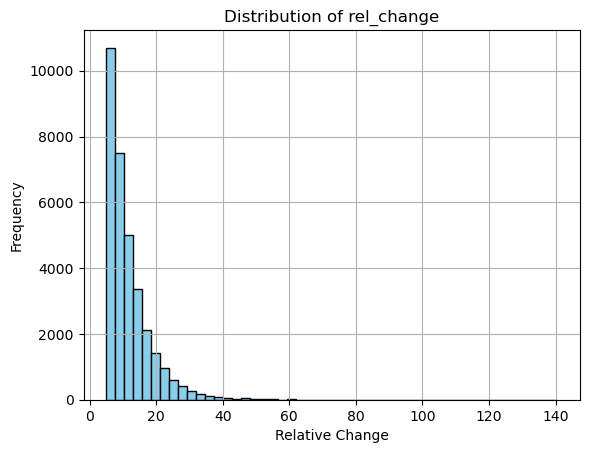

In [4]:
import matplotlib.pyplot as plt

plt.hist(stripes_df['rel_change'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Relative Change')
plt.ylabel('Frequency')
plt.title('Distribution of rel_change')
plt.grid(True)
plt.show()

In [ ]:
len(stripes_df[stripes_df["rel_change"] > 15.0])

In [ ]:
df = stripes_df[stripes_df["rel_change"] > 15.0]

In [5]:
df = stripes_df.nlargest(5000, "rel_change")

In [6]:
# unifying coordinates

# Create a mask for rows in the lower triangle
lower_mask = df['start1'] > df['start2']

# Swap start1/start2 and end1/end2 only for those rows
df.loc[lower_mask, ['start1', 'start2']] = df.loc[lower_mask, ['start2', 'start1']].values
df.loc[lower_mask, ['end1', 'end2']] = df.loc[lower_mask, ['end2', 'end1']].values

In [7]:
# Check how many rows are upper vs lower triangle
upper_triangle = (df['start1'] <= df['start2']).sum()
lower_triangle = (df['start1'] > df['start2']).sum()

print(f"Upper triangle: {upper_triangle}")
print(f"Lower triangle: {lower_triangle}")

Upper triangle: 5000
Lower triangle: 0


In [8]:
from matplotlib.colors import LogNorm

In [55]:
stripe_x_center = (5005024 * 2) + 1000000

In [57]:
stripe_x_center // 2

5505024

In [65]:
# Get stripe info
stripe = stripes_df.iloc[32]
chrom = stripe['chrom1']

# Stripe bounds
stripe_x_start = stripe['start1']
stripe_x_end = stripe['end1']
stripe_y_start = stripe['start2']
stripe_y_end = stripe['end2']

# Stripe vertical center (x-axis) and height
stripe_x_center = (stripe_x_start + stripe_x_end) // 2
stripe_width = stripe_x_end - stripe_x_start

# We'll use the same size for X and Y to keep square view
region_size = max(stripe_width * 4, 1_000_000)  # Can adjust multiplier

# Define region so that stripe is vertically centered
region_start = stripe_x_center - region_size // 2
region_end = stripe_x_center + region_size // 2
region = f"{chrom}:{region_start}-{region_end}"

In [66]:
# Fetch raw (unbalanced) matrix
matrix = clr.matrix(balance=True).fetch(region)

# Plot extents
extents = (region_start, region_end, region_end, region_start)

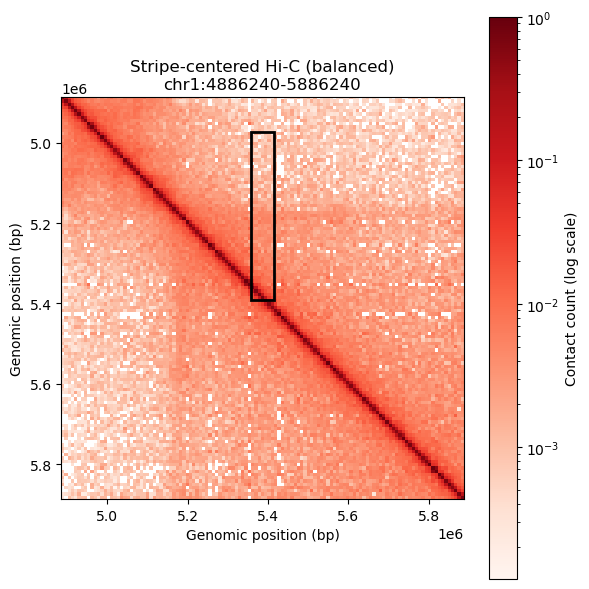

In [67]:
# for balanced data
norm = LogNorm(vmax=1.0)

# Plot
plt.figure(figsize=(6, 6))
plt.imshow(
    matrix,
    cmap='Reds',
    norm=norm,
    extent=extents,
    origin='upper'
)

# Add rectangle or lines to show stripe
# If the stripe is vertical (typical for vertical stripe from loop extrusion):
stripe_rect = patches.Rectangle(
    (stripe_x_start, stripe_y_start),
    stripe_x_end - stripe_x_start,
    stripe_y_end - stripe_y_start,
    linewidth=2,
    edgecolor='black',
    facecolor='none'
)
plt.gca().add_patch(stripe_rect)

# plt.title(f"Stripe-centered Hi-C (raw counts)\n{region}")
plt.title(f"Stripe-centered Hi-C (balanced)\n{region}")
plt.xlabel("Genomic position (bp)")
plt.ylabel("Genomic position (bp)")
plt.colorbar(label="Contact count (log scale)")
plt.tight_layout()
plt.show()